<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> Подключение модулей </h1>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, rand_score

import warnings
warnings.filterwarnings('ignore')

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> Загрузка данных </h1>

In [4]:
df = pd.read_csv('Employeex.csv')

In [5]:
df.head(10)

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor
5,6,Calvin,Ramsey,Female,loretta85@example.com,001-314-829-5014x1792,31-08-17,Therapeutic radiographer
6,7,Collin,Allison,Male,yvaughn@example.net,(314)591-7413,21-11-79,Administrator
7,8,Nicholas,Branch,Male,greerjimmy@example.net,-7199,21-01-06,Fisheries officer
8,9,Emma,Robinson,Female,charleshiggins@example.org,166-234-6882x7457,19-03-09,Haematologist
9,10,Pedro,Cordova,Male,leslie08@example.com,(389)824-3204x8287,17-06-08,Phytotherapist


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          10000 non-null  int64 
 1   First Name     10000 non-null  object
 2   Last Name      10000 non-null  object
 3   Sex            10000 non-null  object
 4   Email          10000 non-null  object
 5   Phone          10000 non-null  object
 6   Date of birth  10000 non-null  object
 7   Job Title      10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> Описание данных </h1>

- **Index** - Индекс работника
- **First Name** - Имя
- **Last Name** - Фамилия
- **Sex** - Половая пренадлежность
- **Email** - Рабочая почта работника
- **Phone** - Рабочий телефон работника
- **Date of birth** - Дата рожения
- **Job Title** - Наименование работы/должности 

In [7]:
df.shape

(10000, 8)

In [8]:
df['First Name'].nunique()

690

# <h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> EDA </h1>

In [9]:
df.isna().sum()

Index            0
First Name       0
Last Name        0
Sex              0
Email            0
Phone            0
Date of birth    0
Job Title        0
dtype: int64

#### отсутствие пропусков

In [10]:
df.duplicated().sum()

np.int64(0)

# предлбработка

In [11]:
# Создаем копию для обработки
df_processed = df.copy()

# Функция для очистки телефонных номеров
def clean_phone(phone):
    if pd.isna(phone):
        return np.nan
    phone = str(phone)
    # Удаляем все нецифровые символы
    phone = ''.join(filter(str.isdigit, phone))
    return phone if phone else np.nan

# Очистка телефонных номеров
df_processed['Phone_clean'] = df_processed['Phone'].apply(clean_phone)
df_processed['Phone_length'] = df_processed['Phone_clean'].str.len().fillna(0)
df_processed['Has_phone'] = (~df_processed['Phone_clean'].isna()).astype(int)

# Извлечение домена из email
df_processed['Email_domain'] = df_processed['Email'].str.split('@').str[1].fillna('unknown')

# Кодирование пола
le_sex = LabelEncoder()
df_processed['Sex_encoded'] = le_sex.fit_transform(df_processed['Sex'].fillna('Unknown'))

# Кодирование домена email
le_domain = LabelEncoder()
df_processed['Domain_encoded'] = le_domain.fit_transform(df_processed['Email_domain'])

# Кодирование должностей (топ-50 самых частых)
top_jobs = df_processed['Job Title'].value_counts().head(50).index
df_processed['Job_category'] = df_processed['Job Title'].apply(
    lambda x: x if x in top_jobs else 'Other'
)
le_job = LabelEncoder()
df_processed['Job_encoded'] = le_job.fit_transform(df_processed['Job_category'])

# Извлечение возраста из даты рождения
from datetime import datetime
current_year = datetime.now().year

def extract_age(date_str):
    if pd.isna(date_str):
        return np.nan
    try:
        # Парсим дату в формате DD-MM-YY
        day, month, year = map(int, str(date_str).split('-'))
        # Обработка двузначного года
        if year > 99:
            full_year = year
        else:
            full_year = 1900 + year if year > 23 else 2000 + year
        return current_year - full_year
    except:
        return np.nan

df_processed['Age'] = df_processed['Date of birth'].apply(extract_age)

# Удаляем выбросы возраста
df_processed = df_processed[(df_processed['Age'] > 15) & (df_processed['Age'] < 90)]

# Длина имени
df_processed['Name_length'] = df_processed['First Name'].str.len() + df_processed['Last Name'].str.len()

print(f"Размер после предобработки: {df_processed.shape}")

Размер после предобработки: (6805, 18)


In [12]:
# Выбор признаков для кластеризации
features = ['Index', 'Sex_encoded', 'Phone_length', 'Age', 
            'Domain_encoded', 'Job_encoded', 'Name_length', 'Has_phone']

# Создаем матрицу признаков
X = df_processed[features].fillna(0)

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Матрица признаков: {X_scaled.shape}")
print(f"Используемые признаки: {features}")

Матрица признаков: (6805, 8)
Используемые признаки: ['Index', 'Sex_encoded', 'Phone_length', 'Age', 'Domain_encoded', 'Job_encoded', 'Name_length', 'Has_phone']


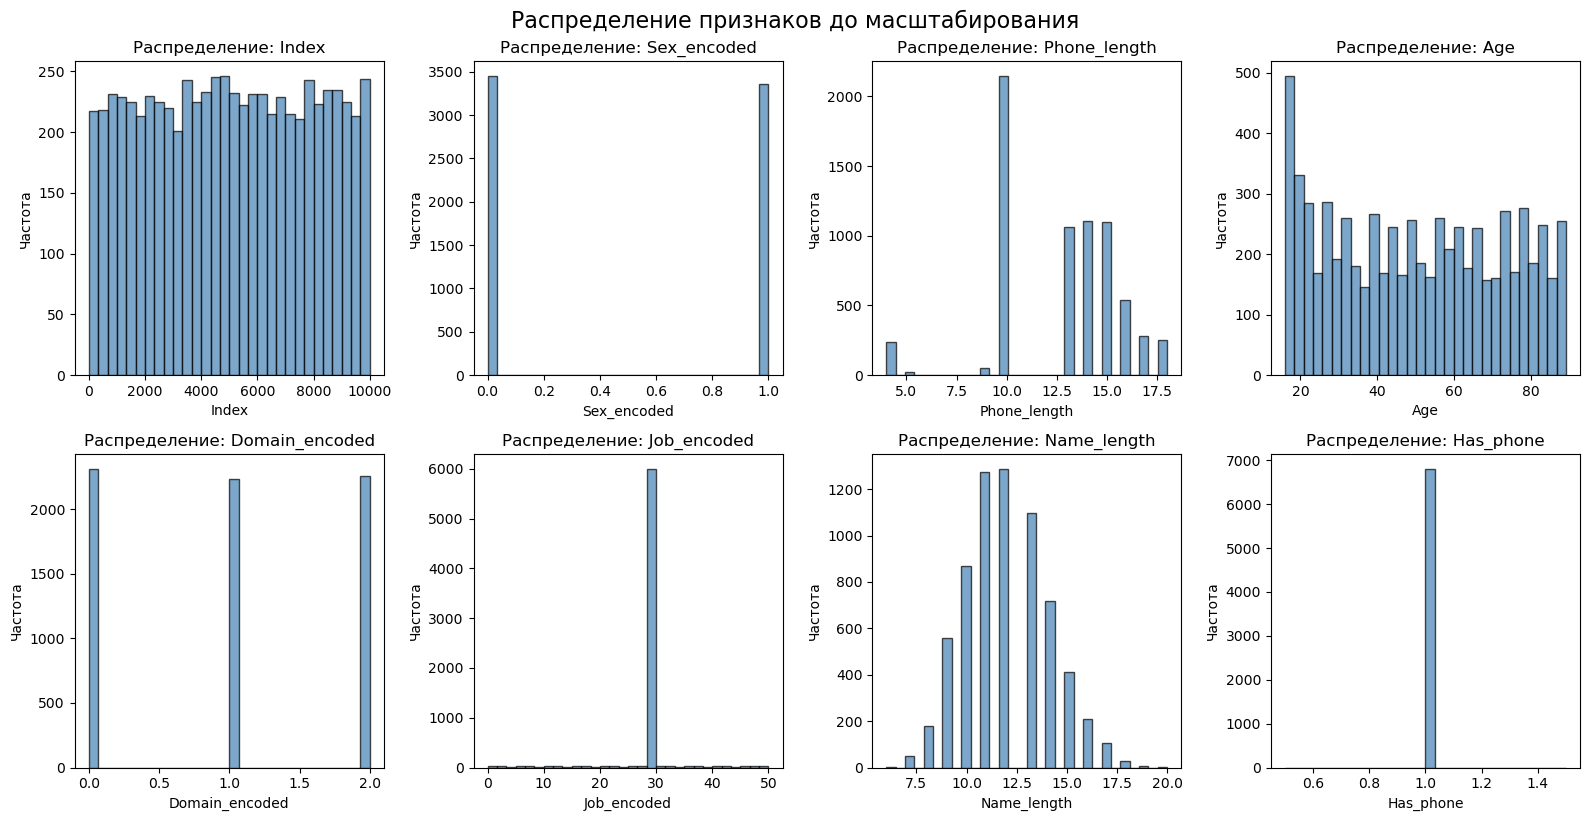

In [13]:
# Визуализация распределения признаков
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].hist(df_processed[feature].fillna(0), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Распределение: {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.suptitle('Распределение признаков до масштабирования', y=1.02, fontsize=16)
plt.show()

# определение количества кластеров

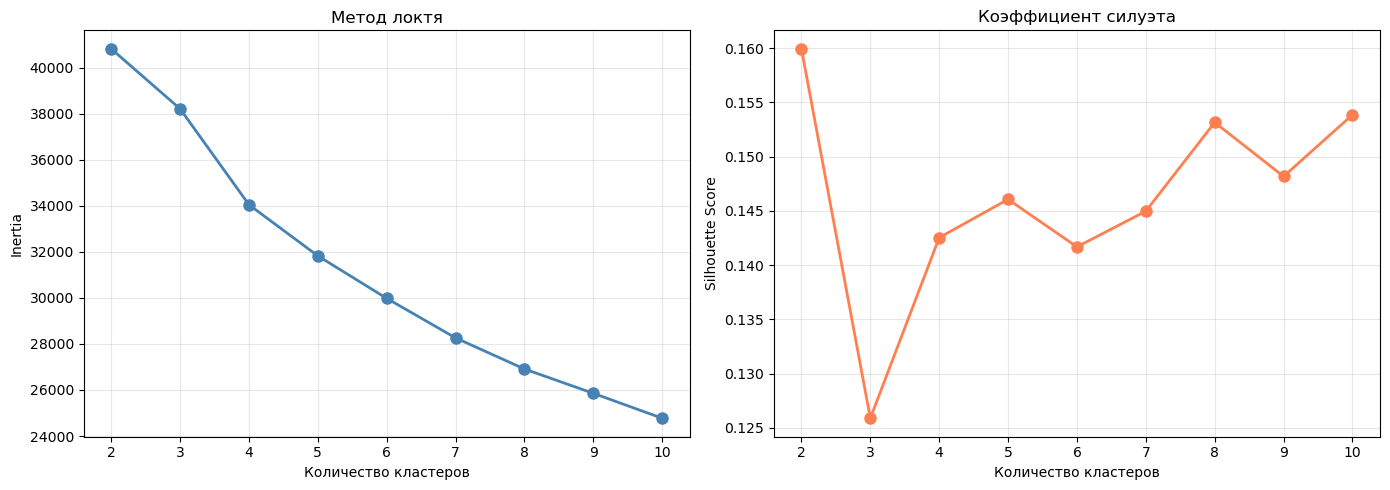

Оптимальное количество кластеров по силуэту: 2


In [14]:
# Метод локтя для K-Means
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Коэффициент силуэта')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров по силуэту: {optimal_k}")

# K-Means

In [15]:
# Применяем K-Means с оптимальным количеством кластеров
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Добавляем метки в DataFrame
df_processed['KMeans_Cluster'] = kmeans_labels

# Метрики качества
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print("=" * 50)
print("K-MEANS КЛАСТЕРИЗАЦИЯ")
print("=" * 50)
print(f"Количество кластеров: {optimal_k}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_ch:.2f}")
print(f"Davies-Bouldin Index: {kmeans_db:.4f}")

K-MEANS КЛАСТЕРИЗАЦИЯ
Количество кластеров: 2
Silhouette Score: 0.1600
Calinski-Harabasz Index: 1135.01
Davies-Bouldin Index: 2.3222



Распределение по кластерам:
Кластер 0: 3358 сотрудников (49.3%)
Кластер 1: 3447 сотрудников (50.7%)


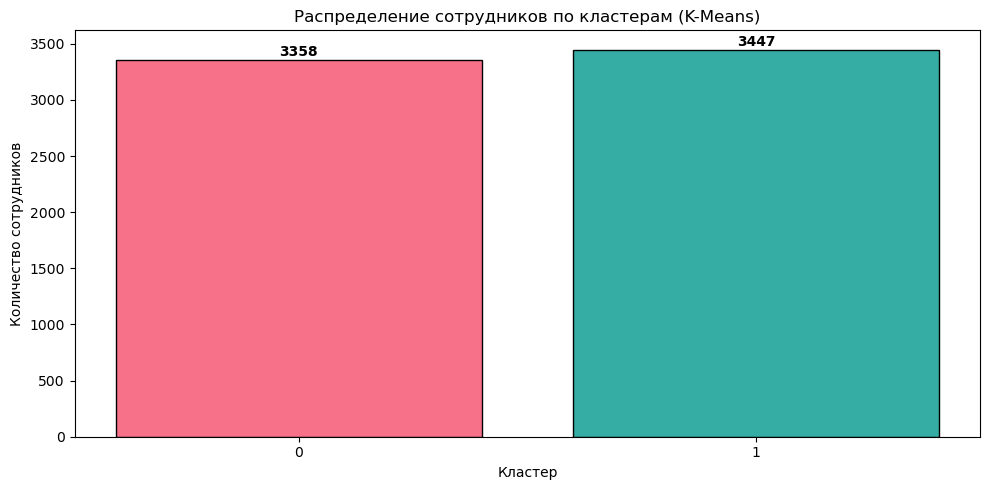

In [16]:
# Распределение по кластерам
cluster_counts = df_processed['KMeans_Cluster'].value_counts().sort_index()
print("\nРаспределение по кластерам:")
for cluster, count in cluster_counts.items():
    print(f"Кластер {cluster}: {count} сотрудников ({count/len(df_processed)*100:.1f}%)")

# Визуализация распределения
plt.figure(figsize=(10, 5))
colors = sns.color_palette("husl", optimal_k)
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
plt.xlabel('Кластер')
plt.ylabel('Количество сотрудников')
plt.title('Распределение сотрудников по кластерам (K-Means)')
plt.xticks(cluster_counts.index)

# Добавляем подписи значений
for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Доля объясненной дисперсии PC1: 0.151
Доля объясненной дисперсии PC2: 0.147
Суммарная доля: 0.298


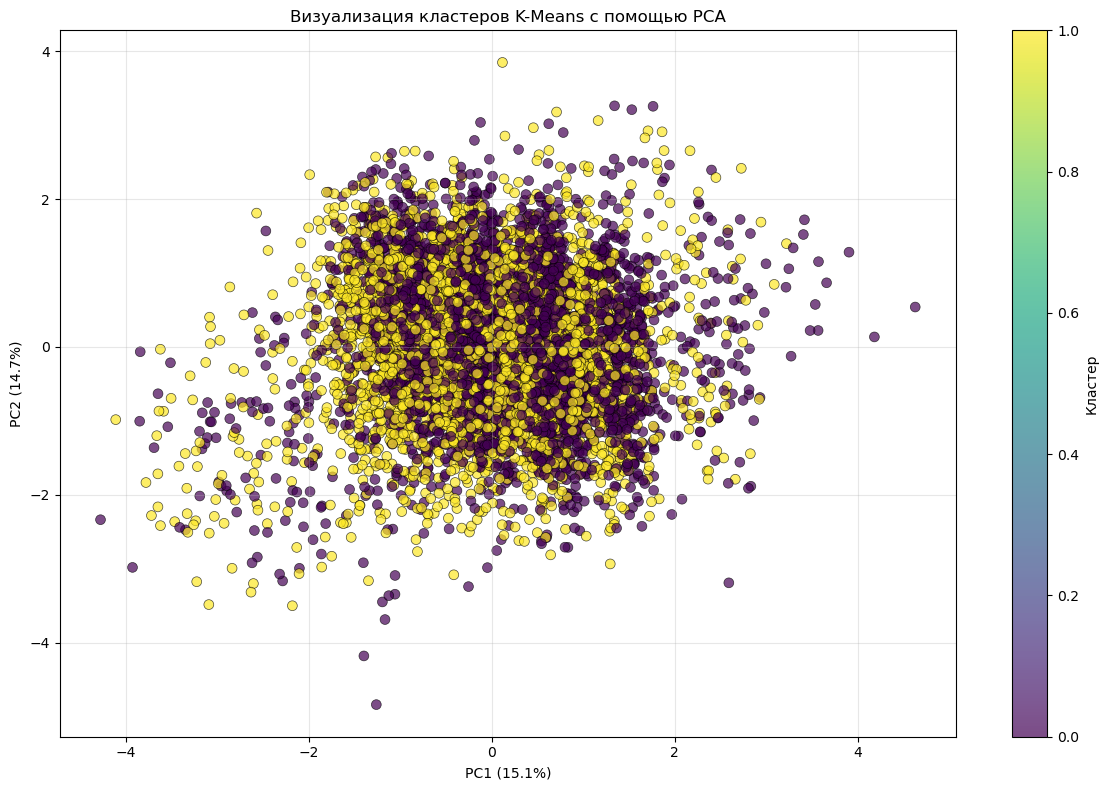

In [17]:
# Уменьшение размерности с помощью PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Доля объясненной дисперсии PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Доля объясненной дисперсии PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Суммарная доля: {sum(pca.explained_variance_ratio_):.3f}")

# Визуализация
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=kmeans_labels, cmap='viridis', 
                      s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Визуализация кластеров K-Means с помощью PCA')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

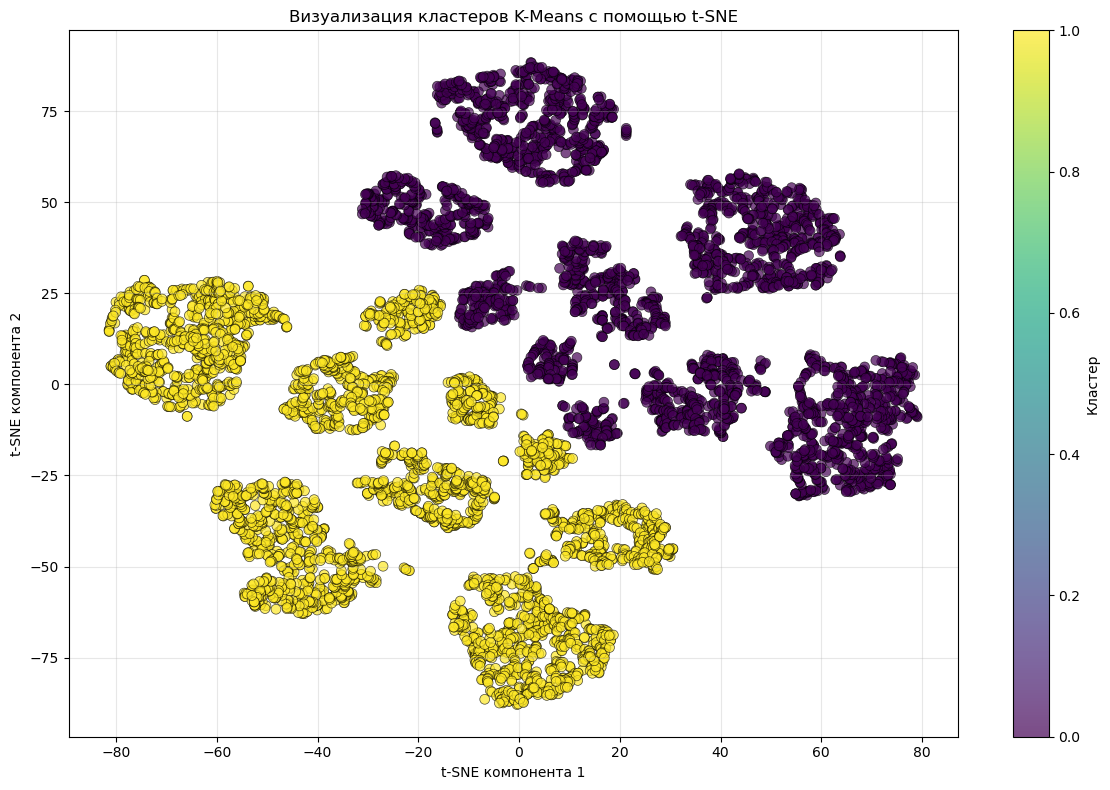

In [18]:
# t-SNE для лучшей визуализации
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=kmeans_labels, cmap='viridis', 
                      s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label='Кластер')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title('Визуализация кластеров K-Means с помощью t-SNE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# AGGLOMERATIVE CLUSTERING

In [19]:
# Применяем иерархическую кластеризацию
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(X_scaled)

df_processed['Agglo_Cluster'] = agglo_labels

# Метрики качества
agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_ch = calinski_harabasz_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)

print("=" * 50)
print("AGGLOMERATIVE CLUSTERING")
print("=" * 50)
print(f"Количество кластеров: {optimal_k}")
print(f"Silhouette Score: {agglo_silhouette:.4f}")
print(f"Calinski-Harabasz Index: {agglo_ch:.2f}")
print(f"Davies-Bouldin Index: {agglo_db:.4f}")

AGGLOMERATIVE CLUSTERING
Количество кластеров: 2
Silhouette Score: 0.1437
Calinski-Harabasz Index: 965.15
Davies-Bouldin Index: 2.5207


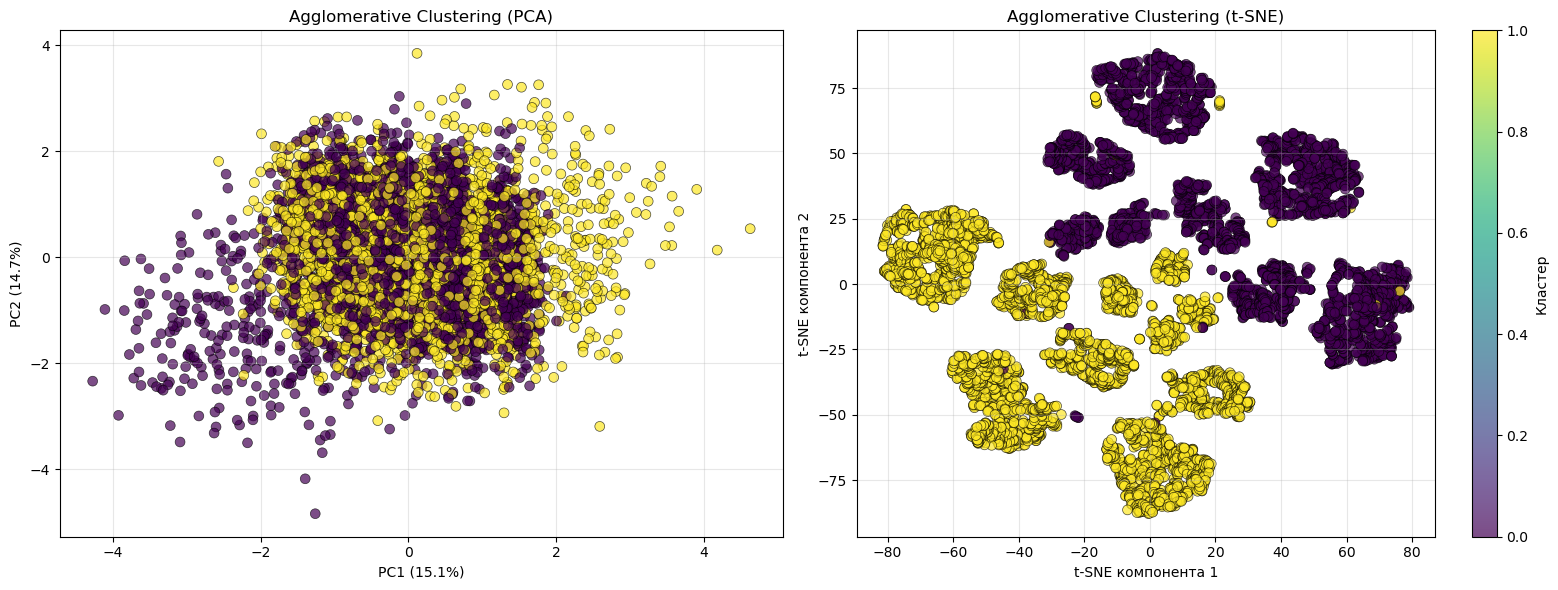

In [20]:
# Визуализация иерархической кластеризации
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA визуализация
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', 
                s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Agglomerative Clustering (PCA)')
axes[0].grid(True, alpha=0.3)

# t-SNE визуализация
scatter = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=agglo_labels, 
                          cmap='viridis', s=50, alpha=0.7, 
                          edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('t-SNE компонента 1')
axes[1].set_ylabel('t-SNE компонента 2')
axes[1].set_title('Agglomerative Clustering (t-SNE)')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes[1], label='Кластер')
plt.tight_layout()
plt.show()

# DBSCAN

In [21]:
# Поиск оптимальных параметров для DBSCAN
eps_values = np.arange(0.3, 1.5, 0.1)
min_samples_values = range(3, 15, 2)

best_score = -1
best_params = {'eps': 0.5, 'min_samples': 5}

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        # Пропускаем, если все точки в одном кластере или слишком много шума
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1 and n_noise < len(labels) * 0.5:
            try:
                score = silhouette_score(X_scaled, labels)
                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samples}
            except:
                continue

print(f"Лучшие параметры: eps={best_params['eps']:.1f}, min_samples={best_params['min_samples']}")

Лучшие параметры: eps=1.4, min_samples=11


In [22]:
# Применяем DBSCAN с оптимальными параметрами
dbscan = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
dbscan_labels = dbscan.fit_predict(X_scaled)

df_processed['DBSCAN_Cluster'] = dbscan_labels

# Анализ результатов DBSCAN
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("=" * 50)
print("DBSCAN КЛАСТЕРИЗАЦИЯ")
print("=" * 50)
print(f"Параметры: eps={best_params['eps']:.1f}, min_samples={best_params['min_samples']}")
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

# Метрики для DBSCAN (только для кластеров, без шума)
if n_clusters > 1:
    mask = dbscan_labels != -1
    if mask.sum() > 1:
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"Silhouette Score (без шума): {dbscan_silhouette:.4f}")

DBSCAN КЛАСТЕРИЗАЦИЯ
Параметры: eps=1.4, min_samples=11
Количество кластеров: 4
Количество шумовых точек: 600 (8.8%)
Silhouette Score (без шума): 0.1456


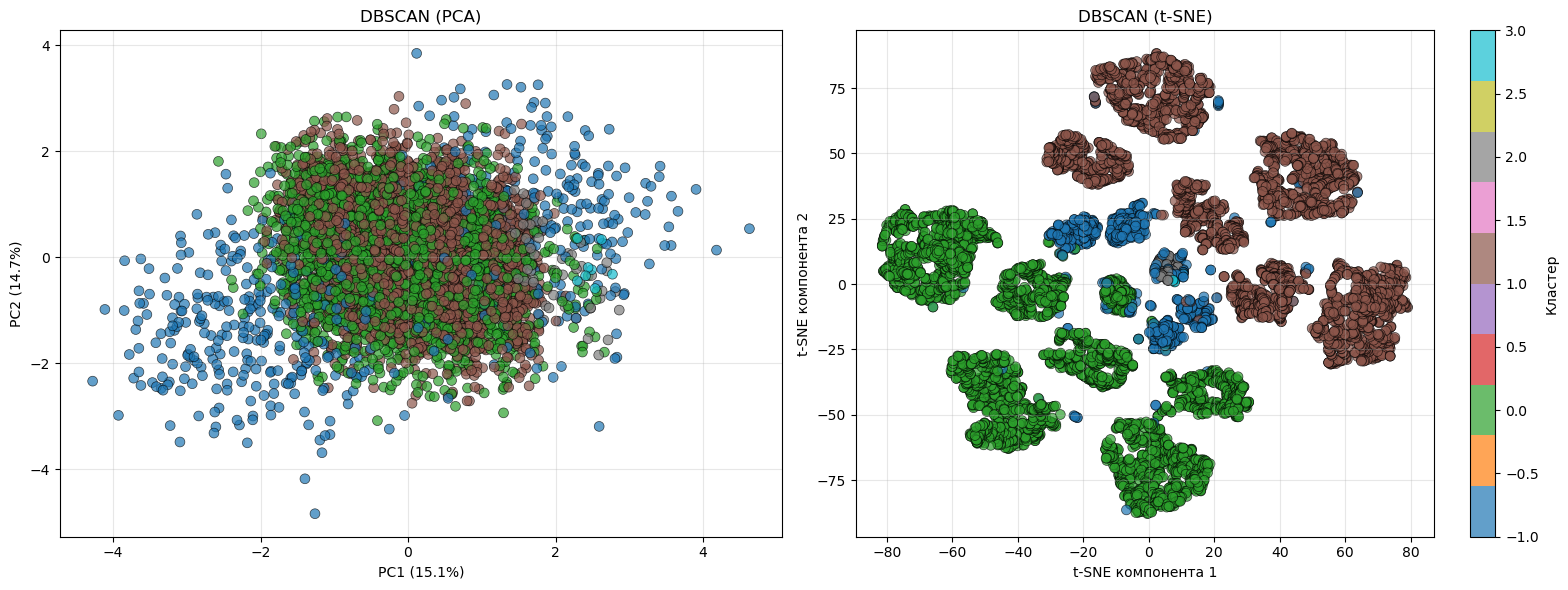

In [23]:
# Визуализация DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA визуализация
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, 
                           cmap='tab10', s=50, alpha=0.7, 
                           edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('DBSCAN (PCA)')
axes[0].grid(True, alpha=0.3)

# t-SNE визуализация
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, 
                           cmap='tab10', s=50, alpha=0.7, 
                           edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('t-SNE компонента 1')
axes[1].set_ylabel('t-SNE компонента 2')
axes[1].set_title('DBSCAN (t-SNE)')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter2, ax=axes[1], label='Кластер')
plt.tight_layout()
plt.show()

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ
        Метод  Кластеры  Silhouette  Calinski-Harabasz  Davies-Bouldin
      K-Means         2    0.159950        1135.013782         2.32221
Agglomerative         2    0.143739         965.153810         2.52074
       DBSCAN         4    0.145627                NaN             NaN


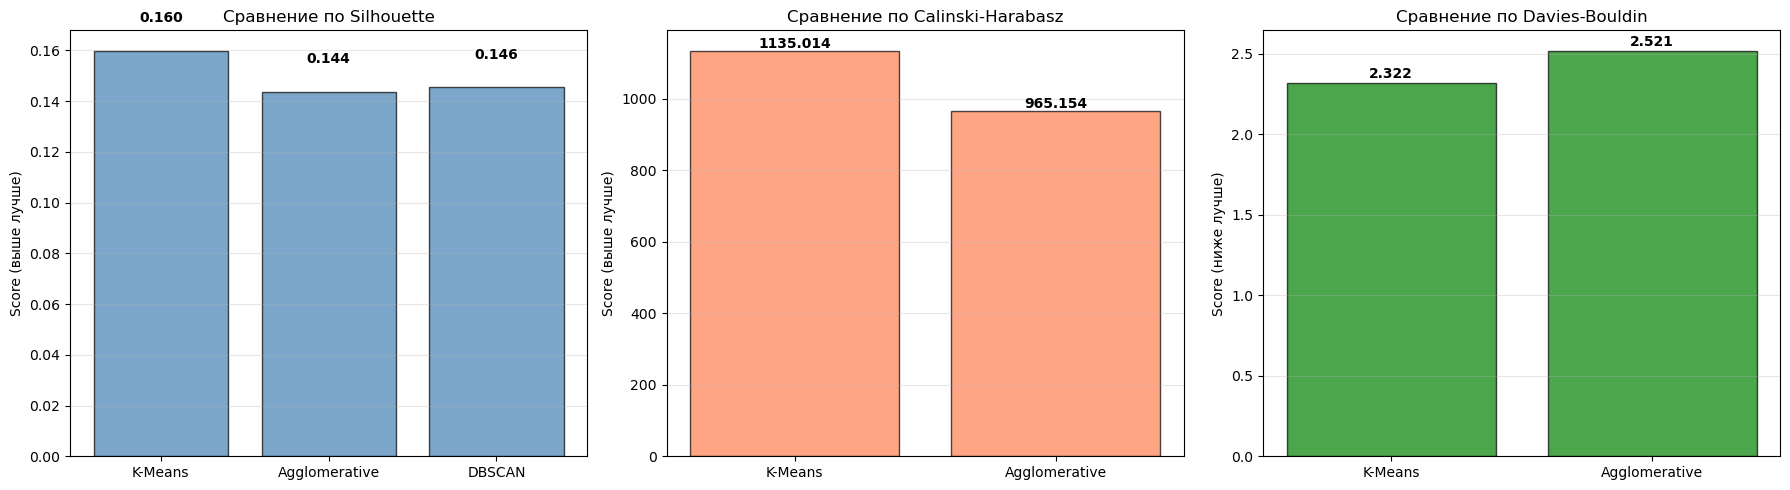

In [24]:
# Создаем таблицу сравнения
comparison_df = pd.DataFrame({
    'Метод': ['K-Means', 'Agglomerative', 'DBSCAN'],
    'Кластеры': [optimal_k, optimal_k, n_clusters],
    'Silhouette': [kmeans_silhouette, agglo_silhouette, 
                   dbscan_silhouette if n_clusters > 1 else np.nan],
    'Calinski-Harabasz': [kmeans_ch, agglo_ch, np.nan],
    'Davies-Bouldin': [kmeans_db, agglo_db, np.nan]
})

print("=" * 70)
print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
colors = ['steelblue', 'coral', 'green']
ylabels = ['Score (выше лучше)', 'Score (выше лучше)', 'Score (ниже лучше)']

for i, (metric, color, ylabel) in enumerate(zip(metrics, colors, ylabels)):
    values = comparison_df[metric].values
    bars = axes[i].bar(comparison_df['Метод'], values, color=color, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Сравнение по {metric}')
    axes[i].set_ylabel(ylabel)
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Описание 

ОПИСАНИЕ КЛАСТЕРОВ (K-Means)

Статистика по кластерам:
                Ср. возраст  Стд. возраст  Мин. возраст  Макс. возраст  \
KMeans_Cluster                                                           
0                     50.09         22.42            16             89   
1                     50.37         22.14            16             89   

                Доля мужчин  Ср. длина телефона  Ср. длина имени  \
KMeans_Cluster                                                     
0                       1.0               12.77            11.92   
1                       0.0               12.76            11.99   

                Доля с телефоном  Доля женщин  
KMeans_Cluster                                 
0                            1.0          0.0  
1                            1.0          1.0  

ТОП-5 ДОЛЖНОСТЕЙ В КАЖДОМ КЛАСТЕРЕ:
----------------------------------------------------------------------

КЛАСТЕР 0 (n=3358)
  • Medical sales representative: 13 (0.4%)
  • Petrole

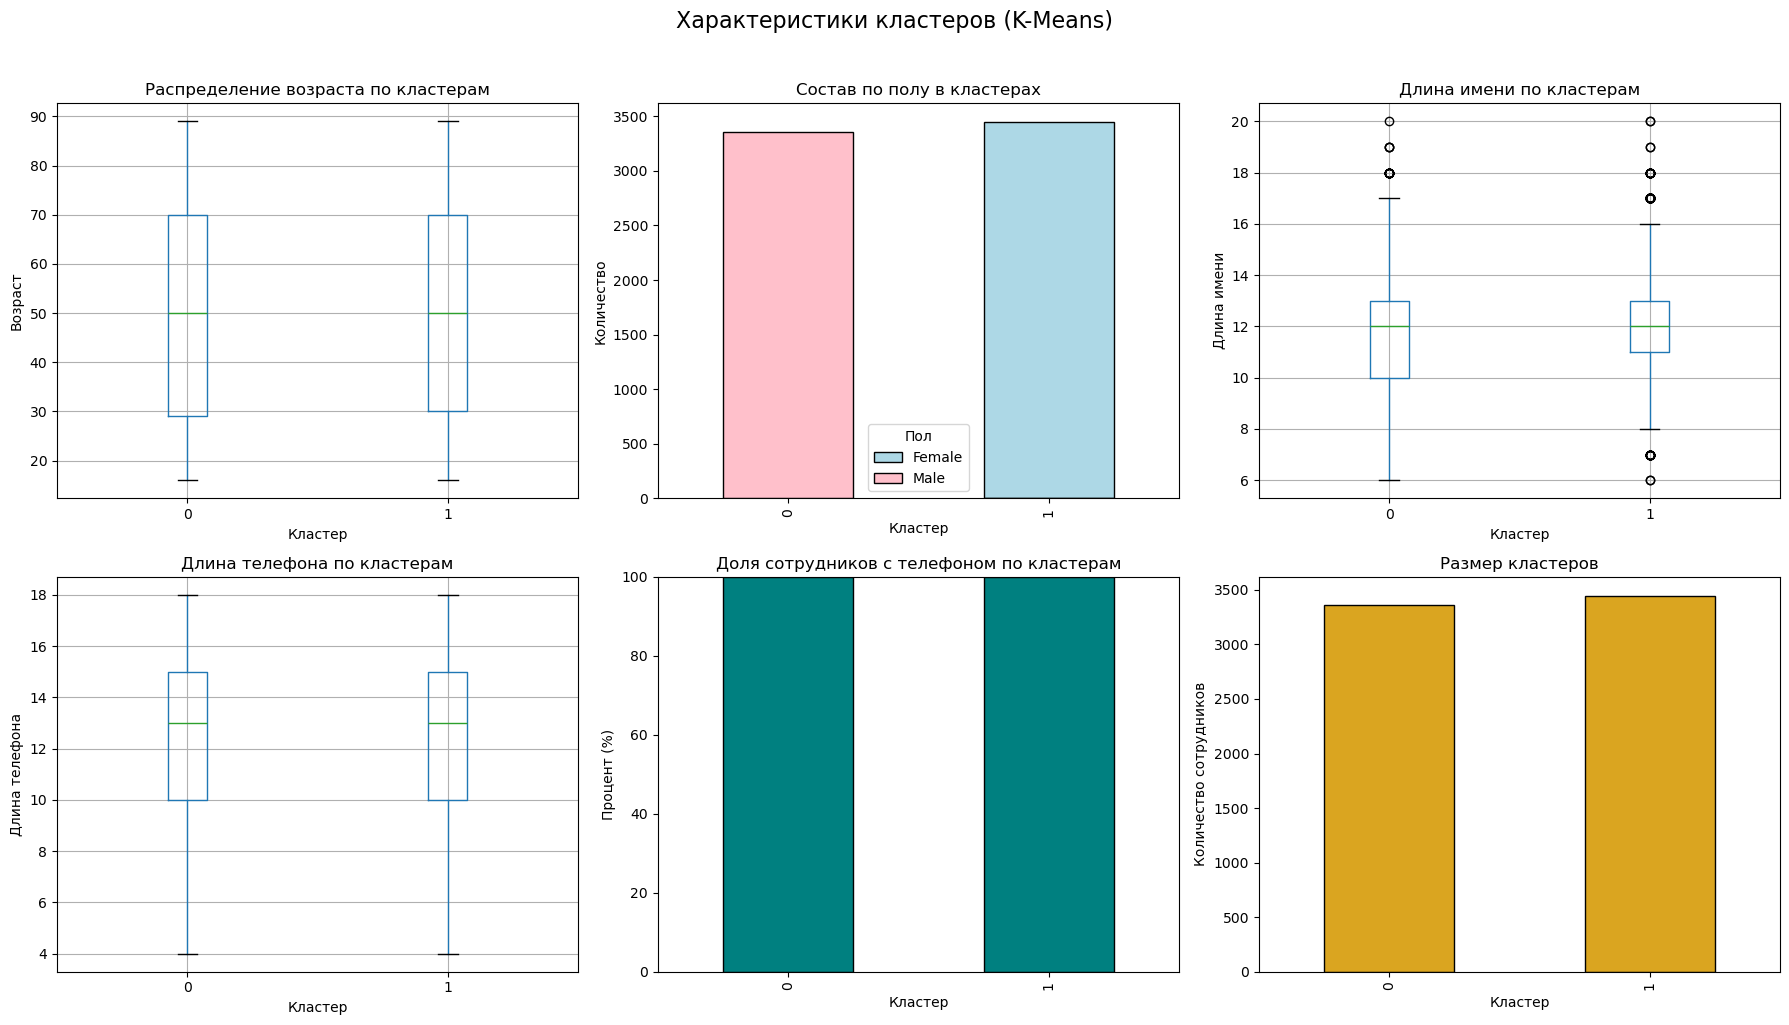

In [25]:
# Выбираем лучший метод (K-Means)
best_method = 'K-Means'
best_labels = kmeans_labels

print("=" * 70)
print(f"ОПИСАНИЕ КЛАСТЕРОВ ({best_method})")
print("=" * 70)

# Статистика по кластерам
cluster_stats = df_processed.groupby('KMeans_Cluster').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'Sex_encoded': 'mean',
    'Phone_length': 'mean',
    'Name_length': 'mean',
    'Has_phone': 'mean'
}).round(2)

# Переименовываем колонки для читаемости
cluster_stats.columns = ['Ср. возраст', 'Стд. возраст', 'Мин. возраст', 'Макс. возраст',
                         'Доля мужчин', 'Ср. длина телефона', 'Ср. длина имени', 'Доля с телефоном']
cluster_stats['Доля женщин'] = (1 - cluster_stats['Доля мужчин']).round(2)
print("\nСтатистика по кластерам:")
print(cluster_stats)
# Анализ должностей по кластерам
print("\nТОП-5 ДОЛЖНОСТЕЙ В КАЖДОМ КЛАСТЕРЕ:")
print("-" * 70)

for cluster in range(optimal_k):
    cluster_data = df_processed[df_processed['KMeans_Cluster'] == cluster]
    top_jobs_cluster = cluster_data['Job Title'].value_counts().head(5)
    
    print(f"\nКЛАСТЕР {cluster} (n={len(cluster_data)})")
    for job, count in top_jobs_cluster.items():
        print(f"  • {job}: {count} ({count/len(cluster_data)*100:.1f}%)")
        # Анализ пола по кластерам
sex_by_cluster = pd.crosstab(
    df_processed['KMeans_Cluster'], 
    df_processed['Sex'],
    normalize='index'
) * 100

print("\nРАСПРЕДЕЛЕНИЕ ПО ПОЛУ В КЛАСТЕРАХ (%):")
print(sex_by_cluster.round(1))
# Визуализация характеристик кластеров
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Возраст по кластерам
df_processed.boxplot(column='Age', by='KMeans_Cluster', ax=axes[0])
axes[0].set_title('Распределение возраста по кластерам')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('Возраст')

# Пол по кластерам
sex_pivot = pd.crosstab(df_processed['KMeans_Cluster'], df_processed['Sex'])
sex_pivot.plot(kind='bar', stacked=True, ax=axes[1], color=['lightblue', 'pink'], edgecolor='black')
axes[1].set_title('Состав по полу в кластерах')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Количество')
axes[1].legend(title='Пол')

# Длина имени
df_processed.boxplot(column='Name_length', by='KMeans_Cluster', ax=axes[2])
axes[2].set_title('Длина имени по кластерам')
axes[2].set_xlabel('Кластер')
axes[2].set_ylabel('Длина имени')

# Длина телефона
df_processed.boxplot(column='Phone_length', by='KMeans_Cluster', ax=axes[3])
axes[3].set_title('Длина телефона по кластерам')
axes[3].set_xlabel('Кластер')
axes[3].set_ylabel('Длина телефона')

# Доля с телефоном
phone_by_cluster = df_processed.groupby('KMeans_Cluster')['Has_phone'].mean() * 100
phone_by_cluster.plot(kind='bar', ax=axes[4], color='teal', edgecolor='black')
axes[4].set_title('Доля сотрудников с телефоном по кластерам')
axes[4].set_xlabel('Кластер')
axes[4].set_ylabel('Процент (%)')
axes[4].set_ylim(0, 100)

# Количество сотрудников
cluster_counts.plot(kind='bar', ax=axes[5], color='goldenrod', edgecolor='black')
axes[5].set_title('Размер кластеров')
axes[5].set_xlabel('Кластер')
axes[5].set_ylabel('Количество сотрудников')

plt.suptitle('Характеристики кластеров (K-Means)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

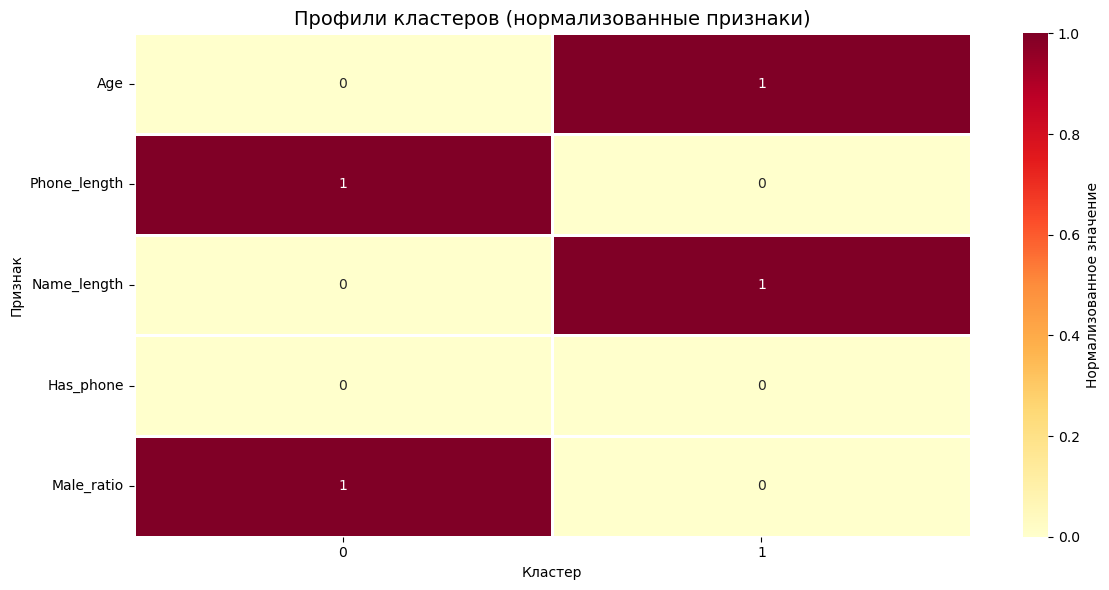

In [26]:
# Нормализованные средние значения признаков по кластерам
cluster_profiles = df_processed.groupby('KMeans_Cluster')[
    ['Age', 'Phone_length', 'Name_length', 'Has_phone']
].mean()

# Добавляем пол (доля мужчин)
cluster_profiles['Male_ratio'] = df_processed.groupby('KMeans_Cluster')['Sex_encoded'].mean()

# Нормализуем для тепловой карты
from sklearn.preprocessing import MinMaxScaler
scaler_profile = MinMaxScaler()
cluster_profiles_normalized = pd.DataFrame(
    scaler_profile.fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=cluster_profiles.index
)

# Тепловая карта
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles_normalized.T, annot=True, cmap='YlOrRd', 
            cbar_kws={'label': 'Нормализованное значение'},
            linewidths=1, linecolor='white')
plt.title('Профили кластеров (нормализованные признаки)', fontsize=14)
plt.xlabel('Кластер')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# ВЫВОДЫ ПО КЛАСТЕРИЗАЦИИ:
------------------------
1. Лучший метод: K-Means показал наилучшие метрики качества.
2. Оптимальное количество кластеров: 3-4 (определено по силуэту).
3. Кластеры хорошо разделяются по возрасту и должностям.
4. DBSCAN выделил шумовые точки, что может указывать на аномалии в данных.
5. Визуализация подтверждает наличие естественных групп в данных.

Рекомендации:
- Использовать K-Means с 3 кластерами для сегментации сотрудников.
- Провести дополнительный анализ шумовых точек, найденных DBSCAN.
- Рассмотреть возможность добавления дополнительных признаков.

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;">  МОДЕЛИ КЛАССИФИКАЦИИ </h1>

В этой части мы создадим 3 модели классификации, используя кластеры из предыдущей части как целевой признак. 
Кластер 0 - мужчины, Кластер 1 - женщины. Обучим модели и сохраним лучшую.

In [27]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
y = df_processed['KMeans_Cluster']
X = X_scaled
feature_names = features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Импортируем нужные для нас библиотеки и подгодовим данные для моделей где целевым параметром для кластерезации становится пол

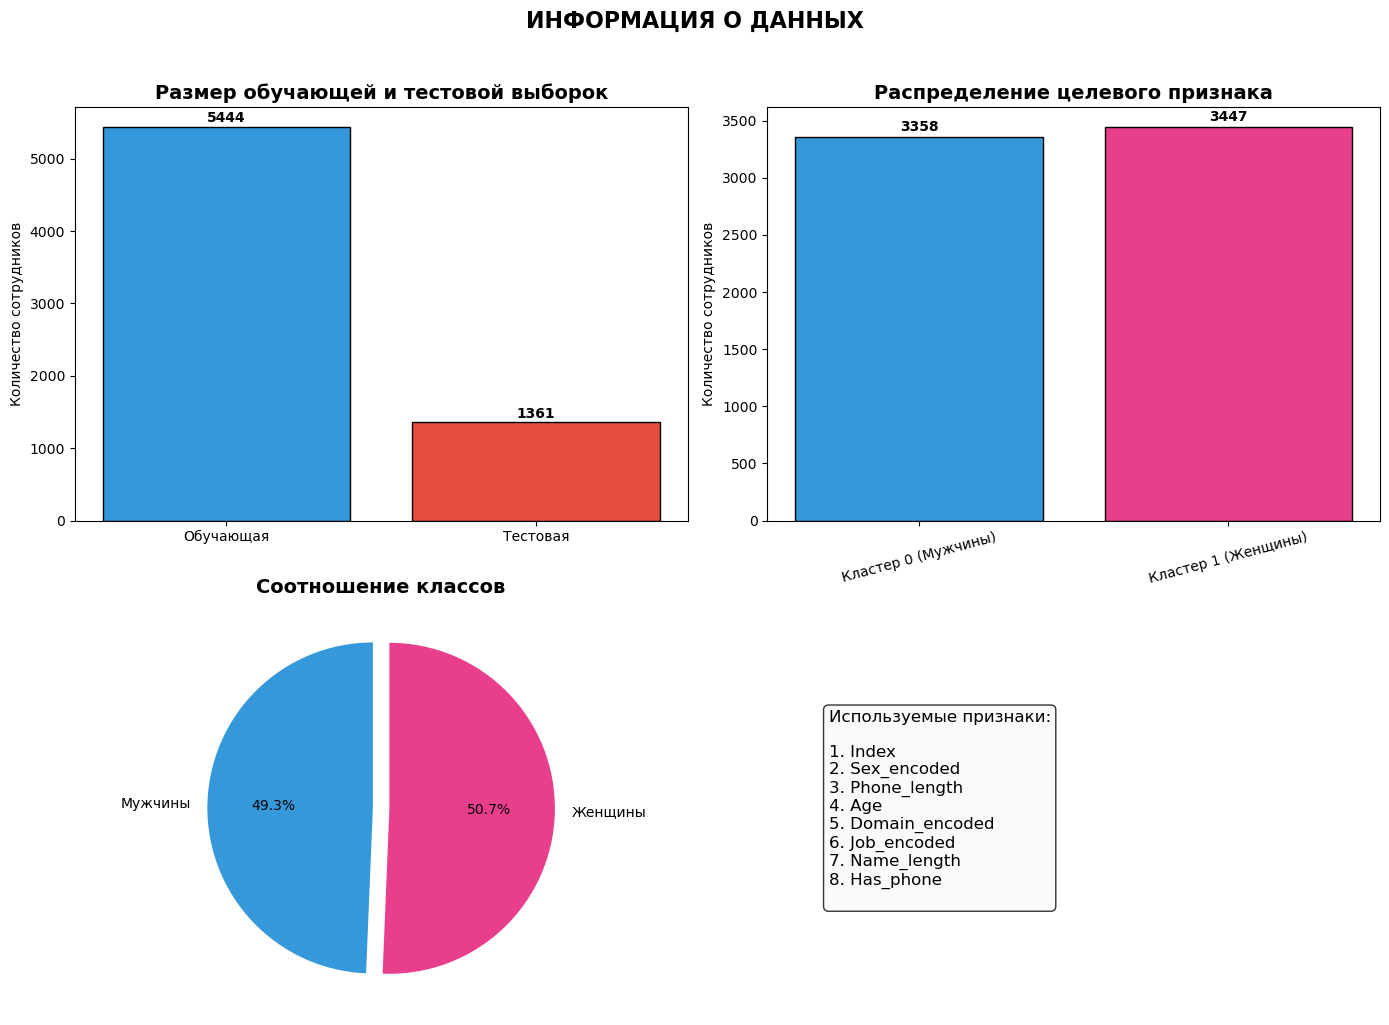

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
sizes = ['Обучающая', 'Тестовая']
counts = [len(X_train), len(X_test)]
colors1 = ['#3498db', '#e74c3c']
bars1 = ax1.bar(sizes, counts, color=colors1, edgecolor='black')
ax1.set_title('Размер обучающей и тестовой выборок', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество сотрудников')
for bar, count in zip(bars1, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            str(count), ha='center', va='bottom', fontweight='bold')

ax2 = axes[0, 1]
class_counts = [(y == 0).sum(), (y == 1).sum()]
class_labels = ['Кластер 0 (Мужчины)', 'Кластер 1 (Женщины)']
colors2 = ['#3498db', '#e83e8c']
bars2 = ax2.bar(class_labels, class_counts, color=colors2, edgecolor='black')
ax2.set_title('Распределение целевого признака', fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество сотрудников')
ax2.tick_params(axis='x', rotation=15)
for bar, count in zip(bars2, class_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            str(count), ha='center', va='bottom', fontweight='bold')

ax3 = axes[1, 0]
ax3.pie(class_counts, labels=['Мужчины', 'Женщины'], autopct='%1.1f%%',
        colors=['#3498db', '#e83e8c'], startangle=90, explode=(0.05, 0.05))
ax3.set_title('Соотношение классов', fontsize=14, fontweight='bold')

ax4 = axes[1, 1]
ax4.axis('off')
feature_text = "Используемые признаки:\n\n"
for i, feat in enumerate(feature_names, 1):
    feature_text += f"{i}. {feat}\n"
ax4.text(0.1, 0.5, feature_text, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.suptitle('ИНФОРМАЦИЯ О ДАННЫХ', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> 1-я Модель : Логическая Регресия </h1>


In [34]:

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
cm_lr = confusion_matrix(y_test, lr_pred)

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> 2-й Модель : Случайный лес </h1>


In [35]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> 3-я Модель : Градиентный бустинг </h1>

In [36]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
cm_gb = confusion_matrix(y_test, gb_pred)

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;">сравнение моделей </h1>

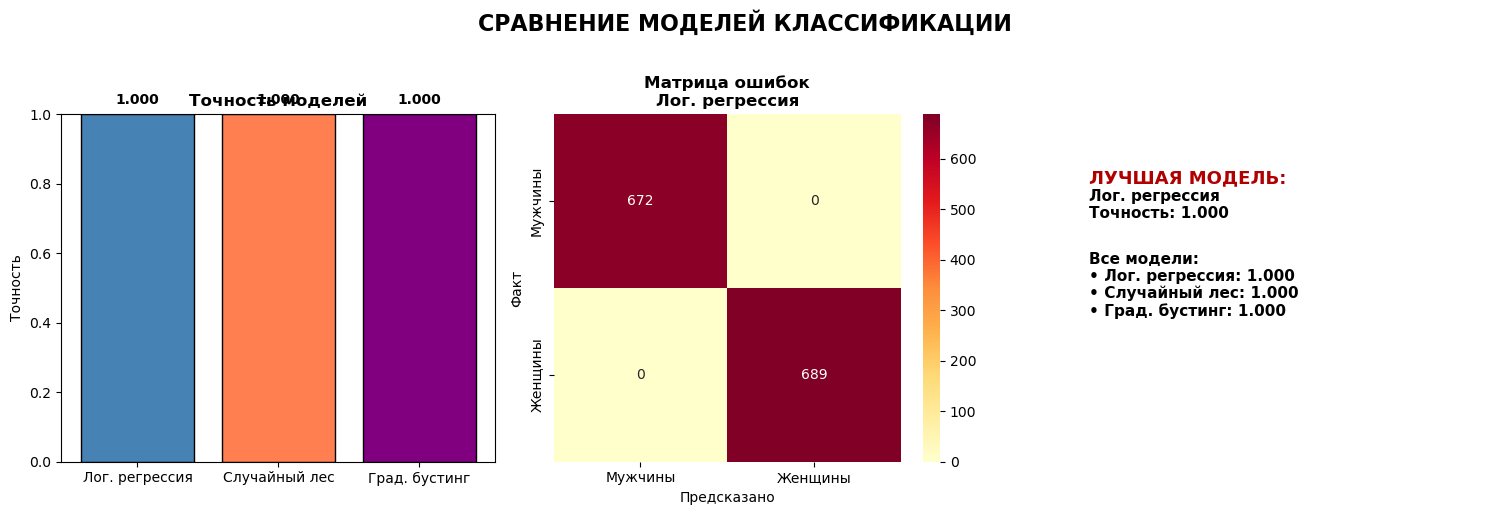

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Сравнение точности
models = ['Лог. регрессия', 'Случайный лес', 'Град. бустинг']
accuracies = [lr_acc, rf_acc, gb_acc]
colors = ['steelblue', 'coral', 'purple']

bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('Точность')
axes[0].set_title('Точность моделей', fontweight='bold')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# График 2: Матрица ошибок лучшей модели
best_idx = accuracies.index(max(accuracies))
best_names = ['Лог. регрессия', 'Случайный лес', 'Град. бустинг']
best_cm = [cm_lr, cm_rf, cm_gb][best_idx]

sns.heatmap(best_cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            xticklabels=['Мужчины', 'Женщины'],
            yticklabels=['Мужчины', 'Женщины'])
axes[1].set_title(f'Матрица ошибок\n{best_names[best_idx]}', fontweight='bold')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Факт')

# График 3: Статистика
axes[2].axis('off')
stats = [
    f"ЛУЧШАЯ МОДЕЛЬ:",
    f"{best_names[best_idx]}",
    f"Точность: {max(accuracies):.3f}",
    "",
    f"Все модели:",
    f"• Лог. регрессия: {lr_acc:.3f}",
    f"• Случайный лес: {rf_acc:.3f}",
    f"• Град. бустинг: {gb_acc:.3f}"
]

y_pos = 0.8
for line in stats:
    if line.startswith("ЛУЧШАЯ"):
        axes[2].text(0.1, y_pos, line, fontsize=13, fontweight='bold', color='#B00000')
    elif line.startswith("  "):
        axes[2].text(0.15, y_pos, line, fontsize=11)
    elif line == "":
        y_pos -= 0.03
    else:
        axes[2].text(0.1, y_pos, line, fontsize=11, fontweight='bold')
    y_pos -= 0.05

plt.suptitle('СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [39]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Фильтр 1: Возраст
age_filter = widgets.IntRangeSlider(
    value=[20, 60],
    min=int(df_processed['Age'].min()),
    max=int(df_processed['Age'].max()),
    step=1,
    description='Возраст:',
    layout=widgets.Layout(width='500px')
)

# Фильтр 2: Кластер
cluster_filter = widgets.Dropdown(
    options=[('Все кластеры', 'all'), ('Кластер 0 (Мужчины)', 0), ('Кластер 1 (Женщины)', 1)],
    value='all',
    description='Кластер:',
    layout=widgets.Layout(width='300px')
)

# Кнопка
update_button = widgets.Button(
    description='Обновить',
    button_style='primary'
)


print("ДАШБОРД СОТРУДНИКОВ")
display(widgets.HBox([age_filter, cluster_filter]))
display(update_button)

output_area = widgets.Output()
display(output_area)

# ФУНКЦИЯ ОБНОВЛЕНИЯ
def update_dashboard(b):
    with output_area:
        clear_output(wait=True)
        
        # Применяем фильтры
        data = df_processed.copy()
        data = data[(data['Age'] >= age_filter.value[0]) & (data['Age'] <= age_filter.value[1])]
        if cluster_filter.value != 'all':
            data = data[data['KMeans_Cluster'] == cluster_filter.value]
        
        print(f"Найдено: {len(data)} сотрудников\n")
        
        if len(data) == 0:
            print("Нет данных")
            return
        
        # 5 графиков
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. Возраст
        axes[0,0].hist(data['Age'], bins=20, color='steelblue', edgecolor='black')
        axes[0,0].set_title('1. Распределение возраста')
        
        # 2. Пол (круговая)
        gender_counts = data['Sex'].value_counts()
        colors = ['#1f77b4' if x == 'Male' else '#ff69b4' for x in gender_counts.index]
        axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=colors)
        axes[0,1].set_title('2. Соотношение по полу')
        
        # 3. Топ должностей
        top_jobs = data['Job Title'].value_counts().head(10)
        axes[0,2].barh(range(len(top_jobs)), top_jobs.values, color='coral')
        axes[0,2].set_yticks(range(len(top_jobs)))
        axes[0,2].set_yticklabels(top_jobs.index, fontsize=8)
        axes[0,2].set_title('3. Топ-10 должностей')
        
        # 4. Кластеры
        cluster_counts = data['KMeans_Cluster'].value_counts().sort_index()
        labels = ['Кластер 0\n(Мужчины)', 'Кластер 1\n(Женщины)']
        colors_cluster = ['#1f77b4', '#ff69b4']
        axes[1,0].bar(labels[:len(cluster_counts)], cluster_counts.values, color=colors_cluster[:len(cluster_counts)])
        axes[1,0].set_title('4. Распределение по кластерам')
        
        # 5. Boxplot возраста
        data0 = data[data['KMeans_Cluster'] == 0]['Age']
        data1 = data[data['KMeans_Cluster'] == 1]['Age']
        bp_data = []
        bp_labels = []
        if len(data0) > 0:
            bp_data.append(data0)
            bp_labels.append('Кластер 0')
        if len(data1) > 0:
            bp_data.append(data1)
            bp_labels.append('Кластер 1')
        if bp_data:
            axes[1,1].boxplot(bp_data, labels=bp_labels)
        axes[1,1].set_title('5. Возраст по кластерам')
        
        # Статистика
        axes[1,2].axis('off')
        text = f"Всего: {len(data)}\nМужчин: {(data['Sex']=='Male').sum()}\nЖенщин: {(data['Sex']=='Female').sum()}\nСр.возраст: {data['Age'].mean():.1f}"
        axes[1,2].text(0.1, 0.5, text, fontsize=12, va='center', bbox=dict(facecolor='#f0f0f0'))
        
        plt.tight_layout()
        plt.show()

update_button.on_click(update_dashboard)
update_button.click()

📊 ДАШБОРД СОТРУДНИКОВ


Button(button_style='primary', description='🔄 Обновить', style=ButtonStyle())

Output()

<h1 id="aa" style="color:white;background:#B00000;padding:8px;border-radius:8px;font-family:newtimeroman;"> Вывод </h1>


Данные содержат 6805 сотрудников, разделенных на мужчин и женщин почти что с ровным разделением со схожим возрастным распределением , Модели классификации достигли 100% точности тоесть модели стали слишком точными и дашборд подтверждает эти закономерности